# **1. Perkenalan Dataset**

## Credit Card Fraud Detection

**Sumber**: [Kaggle - Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
**Pembuat**: Machine Learning Group - ULB (Université Libre de Bruxelles)

### Deskripsi Dataset
Dataset ini berisi transaksi kartu kredit yang dilakukan oleh pemegang kartu di Eropa pada September 2013. Dataset mencakup transaksi selama dua hari, dengan total **284.807 transaksi**, di mana **492 transaksi** teridentifikasi sebagai fraud (penipuan).

### Informasi Fitur
| Fitur | Deskripsi |
|:------|:----------|
| `Time` | Detik yang berlalu antara transaksi ini dengan transaksi pertama dalam dataset |
| `V1` s.d. `V28` | 28 fitur hasil transformasi PCA (Principal Component Analysis) untuk menjaga kerahasiaan data asli |
| `Amount` | Jumlah nominal transaksi |
| `Class` | Label target: **0** = Transaksi Normal, **1** = Transaksi Fraud |

### Karakteristik Utama
- **Sangat Tidak Seimbang (Highly Imbalanced)**: Kelas fraud hanya menyumbang sekitar **0,17%** dari total transaksi
- **Fitur Anonim**: V1-V28 sudah melalui transformasi PCA sehingga tidak bisa diinterpretasi secara langsung
- **Skala Berbeda**: Fitur `Amount` dan `Time` belum distandarisasi, berbeda dengan V1-V28

### Tujuan
Membangun model klasifikasi yang mampu mendeteksi transaksi fraud secara akurat, dengan mempertimbangkan ketidakseimbangan kelas yang ekstrem.

# **2. Import Library**

Pada tahap ini, kita mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
# ============================================================
# Mengimpor pustaka yang dibutuhkan
# ============================================================
import pandas as pd                  # Manipulasi data tabular
import numpy as np                   # Operasi numerik
import matplotlib.pyplot as plt      # Visualisasi dasar
import seaborn as sns                # Visualisasi statistik lanjutan

from sklearn.model_selection import train_test_split  # Pembagian data latih dan uji
from sklearn.preprocessing import StandardScaler      # Standarisasi fitur numerik
from imblearn.over_sampling import SMOTE              # Penanganan data tidak seimbang

import warnings
warnings.filterwarnings('ignore')    # Menyembunyikan peringatan yang tidak relevan

# Konfigurasi tampilan
pd.set_option('display.max_columns', None)   # Tampilkan semua kolom
pd.set_option('display.float_format', '{:.4f}'.format)  # Format angka desimal
sns.set_style('whitegrid')           # Gaya plot seaborn
plt.rcParams['figure.dpi'] = 100     # Resolusi gambar

print("\u2705 Semua pustaka berhasil diimpor.")

✅ Semua pustaka berhasil diimpor.


# **3. Memuat Dataset**

Pada tahap ini, kita memuat dataset Credit Card Fraud Detection dari file CSV ke dalam DataFrame pandas. Setelah dimuat, kita memeriksa struktur awal dataset untuk memastikan data telah terbaca dengan benar.

In [2]:
# ============================================================
# 3.1 Memuat dataset dari file CSV
# ============================================================
jalur_dataset = '../creditcard_raw/creditcard.csv'
df = pd.read_csv(jalur_dataset)

print(f"Dataset berhasil dimuat dari: {jalur_dataset}")
print(f"Dimensi dataset: {df.shape[0]:,} baris x {df.shape[1]} kolom")

Dataset berhasil dimuat dari: ../creditcard_raw/creditcard.csv
Dimensi dataset: 284,807 baris x 31 kolom


In [3]:
# ============================================================
# 3.2 Menampilkan 5 baris pertama dataset
# ============================================================
print("=" * 70)
print("5 BARIS PERTAMA DATASET")
print("=" * 70)
df.head()

5 BARIS PERTAMA DATASET


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


In [4]:
# ============================================================
# 3.3 Menampilkan 5 baris terakhir dataset
# ============================================================
print("=" * 70)
print("5 BARIS TERAKHIR DATASET")
print("=" * 70)
df.tail()

5 BARIS TERAKHIR DATASET


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0000,-11.8811,10.0718,-9.8348,-2.0667,-5.3645,-2.6068,-4.9182,7.3053,1.9144,4.3562,-1.5931,2.7119,-0.6893,4.6269,-0.9245,1.1076,1.9917,0.5106,-0.6829,1.4758,0.2135,0.1119,1.0145,-0.5093,1.4368,0.2500,0.9437,0.8237,0.7700,0
284803,172787.0000,-0.7328,-0.0551,2.0350,-0.7386,0.8682,1.0584,0.0243,0.2949,0.5848,-0.9759,-0.1502,0.9158,1.2148,-0.6751,1.1649,-0.7118,-0.0257,-1.2212,-1.5456,0.0596,0.2142,0.9244,0.0125,-1.0162,-0.6066,-0.3953,0.0685,-0.0535,24.7900,0
284804,172788.0000,1.9196,-0.3013,-3.2496,-0.5578,2.6305,3.0313,-0.2968,0.7084,0.4325,-0.4848,0.4116,0.0631,-0.1837,-0.5106,1.3293,0.1407,0.3135,0.3957,-0.5773,0.0014,0.2320,0.5782,-0.0375,0.6401,0.2657,-0.0874,0.0045,-0.0266,67.8800,0
284805,172788.0000,-0.2404,0.5305,0.7025,0.6898,-0.3780,0.6237,-0.6862,0.6791,0.3921,-0.3991,-1.9338,-0.9629,-1.0421,0.4496,1.9626,-0.6086,0.5099,1.1140,2.8978,0.1274,0.2652,0.8000,-0.1633,0.1232,-0.5692,0.5467,0.1088,0.1045,10.0000,0
284806,172792.0000,-0.5334,-0.1897,0.7033,-0.5063,-0.0125,-0.6496,1.5770,-0.4147,0.4862,-0.9154,-1.0405,-0.0315,-0.1881,-0.0843,0.0413,-0.3026,-0.6604,0.1674,-0.2561,0.3829,0.2611,0.6431,0.3768,0.0088,-0.4736,-0.8183,-0.0024,0.0136,217.0000,0


In [5]:
# ============================================================
# 3.4 Memeriksa tipe data dan informasi umum
# ============================================================
print("=" * 70)
print("INFORMASI UMUM DATASET")
print("=" * 70)
df.info()

INFORMASI UMUM DATASET
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21

In [6]:
# ============================================================
# 3.5 Statistik deskriptif dataset
# ============================================================
print("=" * 70)
print("STATISTIK DESKRIPTIF")
print("=" * 70)
df.describe()

STATISTIK DESKRIPTIF


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000
mean,94813.8596,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,88.3496,0.0017
std,47488.1460,1.9587,1.6513,1.5163,1.4159,1.3802,1.3323,1.2371,1.1944,1.0986,1.0888,1.0207,0.9992,0.9953,0.9586,0.9153,0.8763,0.8493,0.8382,0.8140,0.7709,0.7345,0.7257,0.6245,0.6056,0.5213,0.4822,0.4036,0.3301,250.1201,0.0415
min,0.0000,-56.4075,-72.7157,-48.3256,-5.6832,-113.7433,-26.1605,-43.5572,-73.2167,-13.4341,-24.5883,-4.7975,-18.6837,-5.7919,-19.2143,-4.4989,-14.1299,-25.1628,-9.4987,-7.2135,-54.4977,-34.8304,-10.9331,-44.8077,-2.8366,-10.2954,-2.6046,-22.5657,-15.4301,0.0000,0.0000
25%,54201.5000,-0.9204,-0.5985,-0.8904,-0.8486,-0.6916,-0.7683,-0.5541,-0.2086,-0.6431,-0.5354,-0.7625,-0.4056,-0.6485,-0.4256,-0.5829,-0.4680,-0.4837,-0.4988,-0.4563,-0.2117,-0.2284,-0.5424,-0.1618,-0.3546,-0.3171,-0.3270,-0.0708,-0.0530,5.6000,0.0000
50%,84692.0000,0.0181,0.0655,0.1798,-0.0198,-0.0543,-0.2742,0.0401,0.0224,-0.0514,-0.0929,-0.0328,0.1400,-0.0136,0.0506,0.0481,0.0664,-0.0657,-0.0036,0.0037,-0.0625,-0.0295,0.0068,-0.0112,0.0410,0.0166,-0.0521,0.0013,0.0112,22.0000,0.0000
75%,139320.5000,1.3156,0.8037,1.0272,0.7433,0.6119,0.3986,0.5704,0.3273,0.5971,0.4539,0.7396,0.6182,0.6625,0.4931,0.6488,0.5233,0.3997,0.5008,0.4589,0.1330,0.1864,0.5286,0.1476,0.4395,0.3507,0.2410,0.0910,0.0783,77.1650,0.0000
max,172792.0000,2.4549,22.0577,9.3826,16.8753,34.8017,73.3016,120.5895,20.0072,15.5950,23.7451,12.0189,7.8484,7.1269,10.5268,8.8777,17.3151,9.2535,5.0411,5.5920,39.4209,27.2028,10.5031,22.5284,4.5845,7.5196,3.5173,31.6122,33.8478,25691.1600,1.0000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, kita melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset secara mendalam. Tujuan EDA adalah memperoleh wawasan awal mengenai distribusi data, hubungan antar fitur, dan potensi masalah yang perlu ditangani pada tahap preprocessing.

DISTRIBUSI KELAS TARGET
Transaksi Normal :    284,315 (99.8273%)
Transaksi Fraud  :        492 (0.1727%)
Rasio Fraud      : 1 : 577


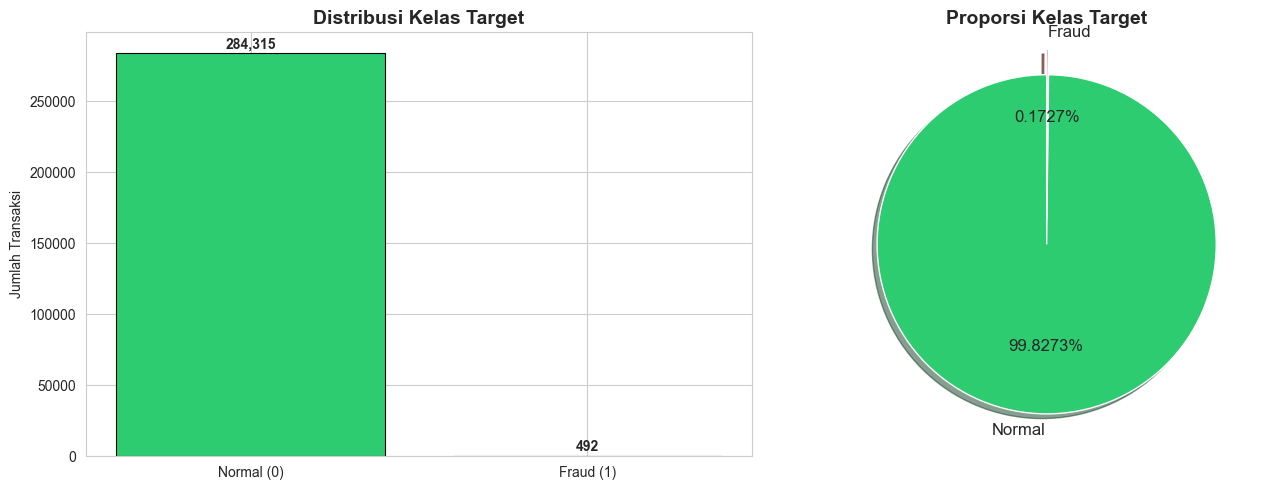


⚠️ Kesimpulan: Dataset SANGAT TIDAK SEIMBANG. Diperlukan teknik
   penanganan khusus (SMOTE/undersampling) pada tahap preprocessing.


In [7]:
# ============================================================
# 4.1 Distribusi Kelas Target (Class Imbalance)
# ============================================================
jumlah_per_kelas = df['Class'].value_counts()
persentase_fraud = (jumlah_per_kelas[1] / len(df)) * 100

print("=" * 50)
print("DISTRIBUSI KELAS TARGET")
print("=" * 50)
print(f"Transaksi Normal : {jumlah_per_kelas[0]:>10,} ({100 - persentase_fraud:.4f}%)")
print(f"Transaksi Fraud  : {jumlah_per_kelas[1]:>10,} ({persentase_fraud:.4f}%)")
print(f"Rasio Fraud      : 1 : {int(jumlah_per_kelas[0] / jumlah_per_kelas[1])}")

# Visualisasi
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

warna = ['#2ecc71', '#e74c3c']

# Bar chart
batang = ax[0].bar(['Normal (0)', 'Fraud (1)'], jumlah_per_kelas.values,
                   color=warna, edgecolor='black', linewidth=0.8)
ax[0].set_title('Distribusi Kelas Target', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Jumlah Transaksi')
for bar_item, nilai in zip(batang, jumlah_per_kelas.values):
    ax[0].text(bar_item.get_x() + bar_item.get_width()/2., bar_item.get_height() + 1000,
              f'{nilai:,}', ha='center', va='bottom', fontweight='bold')

# Pie chart
ax[1].pie(jumlah_per_kelas, labels=['Normal', 'Fraud'], autopct='%1.4f%%',
          colors=warna, startangle=90, explode=[0, 0.15],
          textprops={'fontsize': 12}, shadow=True)
ax[1].set_title('Proporsi Kelas Target', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n\u26a0\ufe0f Kesimpulan: Dataset SANGAT TIDAK SEIMBANG. Diperlukan teknik\n"
      "   penanganan khusus (SMOTE/undersampling) pada tahap preprocessing.")

In [8]:
# ============================================================
# 4.2 Memeriksa Missing Values dan Data Duplikat
# ============================================================
print("=" * 50)
print("PEMERIKSAAN MISSING VALUES")
print("=" * 50)

total_missing = df.isnull().sum().sum()
print(f"Total missing values di seluruh dataset: {total_missing}")

if total_missing > 0:
    print("\nDetail missing values per kolom:")
    kolom_missing = df.isnull().sum()
    print(kolom_missing[kolom_missing > 0])
else:
    print("\u2705 Tidak ada missing values di dataset ini.")

print("\n" + "=" * 50)
print("PEMERIKSAAN DATA DUPLIKAT")
print("=" * 50)

jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat: {jumlah_duplikat:,}")

if jumlah_duplikat > 0:
    print(f"\u26a0\ufe0f Ditemukan {jumlah_duplikat:,} baris duplikat yang perlu dihapus pada tahap preprocessing.")
else:
    print("\u2705 Tidak ada data duplikat.")

PEMERIKSAAN MISSING VALUES
Total missing values di seluruh dataset: 0
✅ Tidak ada missing values di dataset ini.

PEMERIKSAAN DATA DUPLIKAT


Jumlah baris duplikat: 1,081
⚠️ Ditemukan 1,081 baris duplikat yang perlu dihapus pada tahap preprocessing.


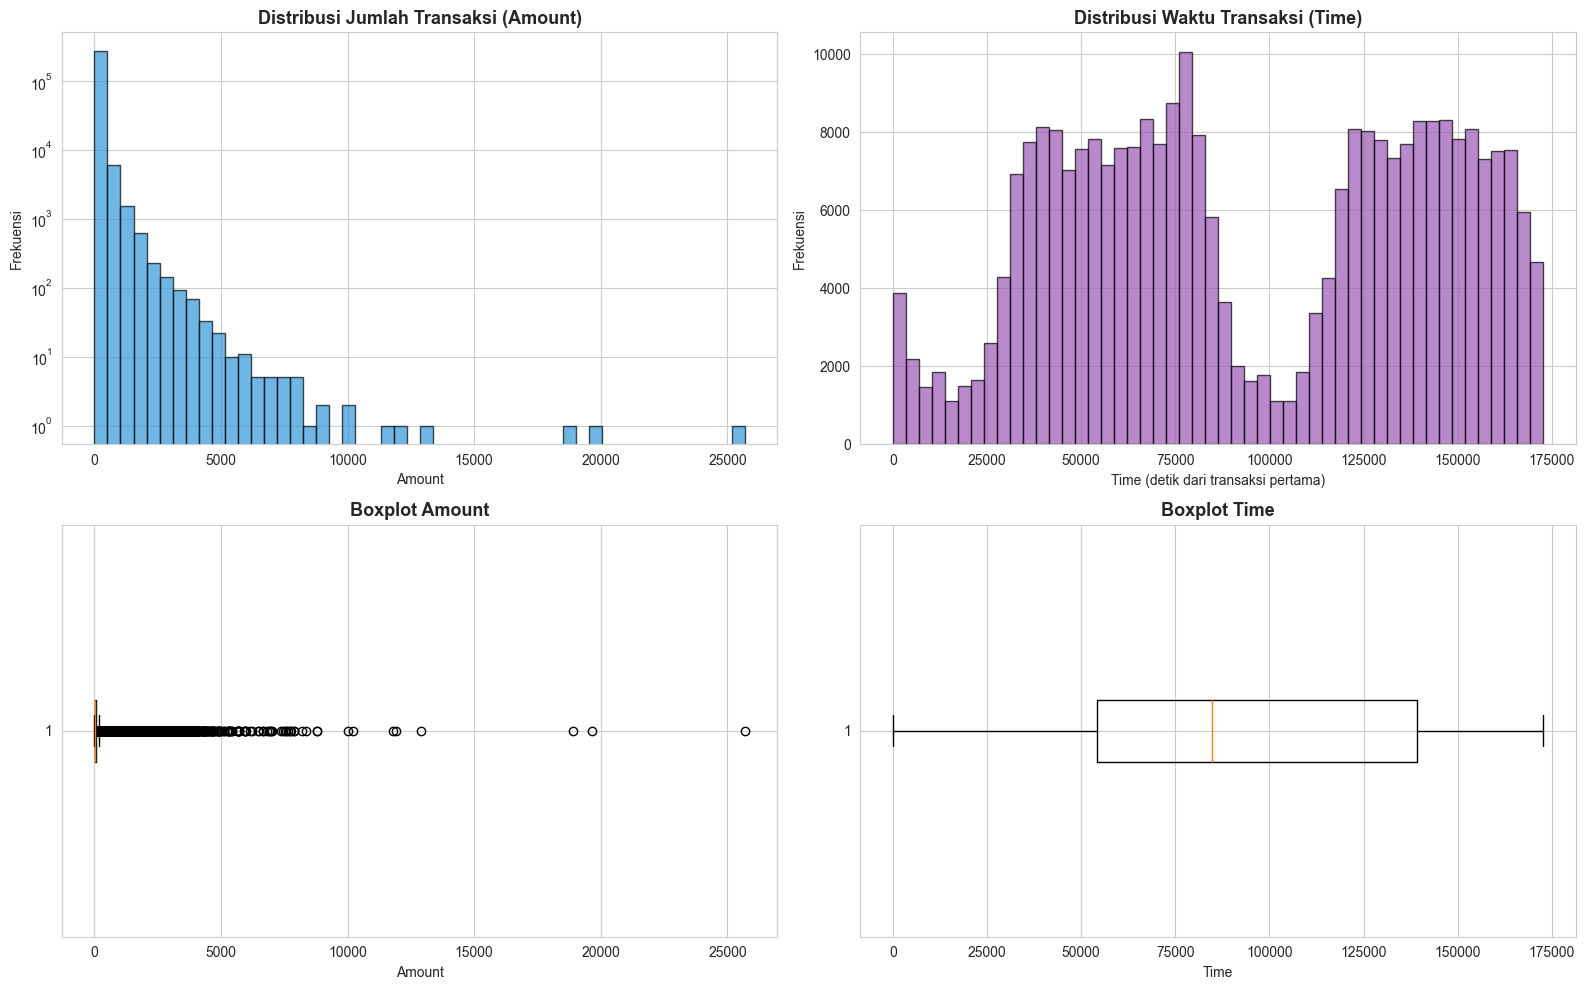


Statistik Amount:
  Min     : 0.00
  Max     : 25691.16
  Median  : 22.00
  Mean    : 88.35
  Std Dev : 250.12


In [9]:
# ============================================================
# 4.3 Distribusi Fitur 'Amount' dan 'Time'
# ============================================================
fig, ax = plt.subplots(2, 2, figsize=(16, 10))

# Histogram Amount
ax[0, 0].hist(df['Amount'], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
ax[0, 0].set_title('Distribusi Jumlah Transaksi (Amount)', fontsize=13, fontweight='bold')
ax[0, 0].set_xlabel('Amount')
ax[0, 0].set_ylabel('Frekuensi')
ax[0, 0].set_yscale('log')  # Skala logaritmik karena range sangat lebar

# Histogram Time
ax[0, 1].hist(df['Time'], bins=50, color='#9b59b6', edgecolor='black', alpha=0.7)
ax[0, 1].set_title('Distribusi Waktu Transaksi (Time)', fontsize=13, fontweight='bold')
ax[0, 1].set_xlabel('Time (detik dari transaksi pertama)')
ax[0, 1].set_ylabel('Frekuensi')

# Boxplot Amount
ax[1, 0].boxplot(df['Amount'].values, vert=False)
ax[1, 0].set_title('Boxplot Amount', fontsize=13, fontweight='bold')
ax[1, 0].set_xlabel('Amount')

# Boxplot Time
ax[1, 1].boxplot(df['Time'].values, vert=False)
ax[1, 1].set_title('Boxplot Time', fontsize=13, fontweight='bold')
ax[1, 1].set_xlabel('Time')

plt.tight_layout()
plt.show()

print("\nStatistik Amount:")
print(f"  Min     : {df['Amount'].min():.2f}")
print(f"  Max     : {df['Amount'].max():.2f}")
print(f"  Median  : {df['Amount'].median():.2f}")
print(f"  Mean    : {df['Amount'].mean():.2f}")
print(f"  Std Dev : {df['Amount'].std():.2f}")

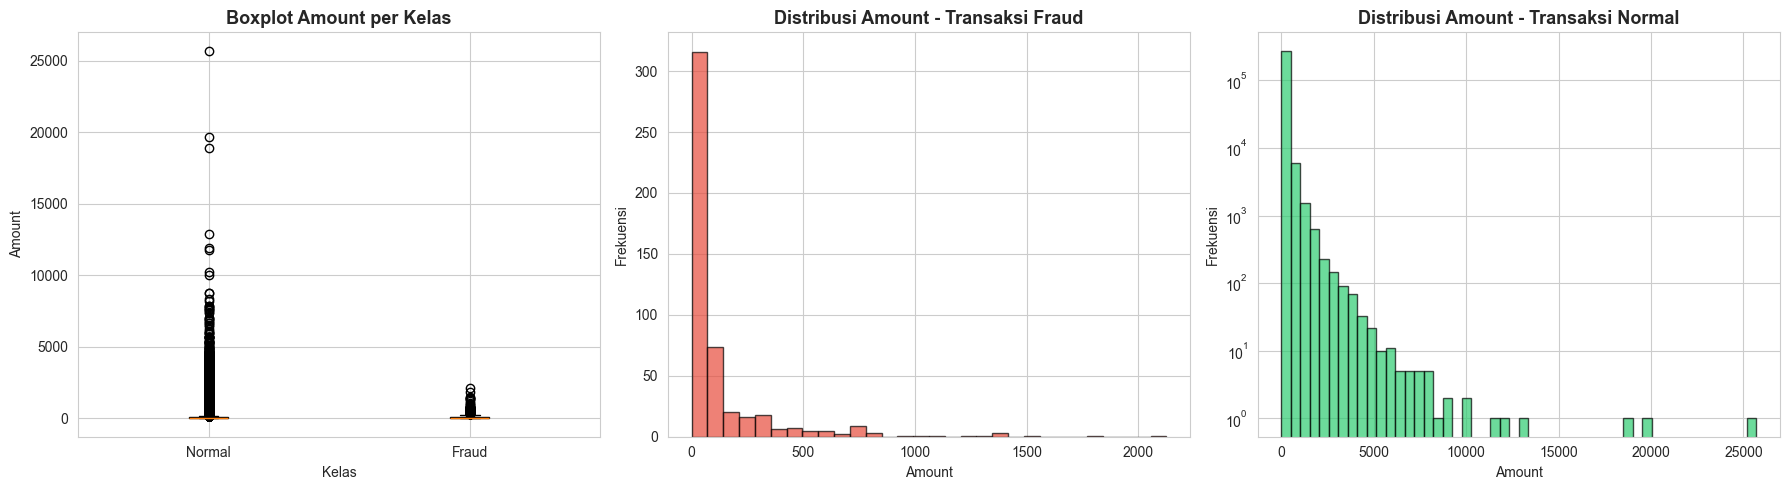

Rata-rata Amount Normal : 88.29
Rata-rata Amount Fraud  : 122.21


In [10]:
# ============================================================
# 4.4 Perbandingan Distribusi Amount: Fraud vs Normal
# ============================================================
df_normal = df[df['Class'] == 0]
df_fraud = df[df['Class'] == 1]

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Boxplot Amount berdasarkan Kelas
data_boxplot = [df_normal['Amount'].values, df_fraud['Amount'].values]
bp = ax[0].boxplot(data_boxplot, labels=['Normal', 'Fraud'], patch_artist=True)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
ax[0].set_title('Boxplot Amount per Kelas', fontsize=13, fontweight='bold')
ax[0].set_xlabel('Kelas')
ax[0].set_ylabel('Amount')

# Histogram Amount untuk Fraud saja
ax[1].hist(df_fraud['Amount'], bins=30, color='#e74c3c', edgecolor='black', alpha=0.7)
ax[1].set_title('Distribusi Amount - Transaksi Fraud', fontsize=13, fontweight='bold')
ax[1].set_xlabel('Amount')
ax[1].set_ylabel('Frekuensi')

# Histogram Amount untuk Normal saja
ax[2].hist(df_normal['Amount'], bins=50, color='#2ecc71', edgecolor='black', alpha=0.7)
ax[2].set_title('Distribusi Amount - Transaksi Normal', fontsize=13, fontweight='bold')
ax[2].set_xlabel('Amount')
ax[2].set_ylabel('Frekuensi')
ax[2].set_yscale('log')

plt.tight_layout()
plt.show()

print(f"Rata-rata Amount Normal : {df_normal['Amount'].mean():.2f}")
print(f"Rata-rata Amount Fraud  : {df_fraud['Amount'].mean():.2f}")

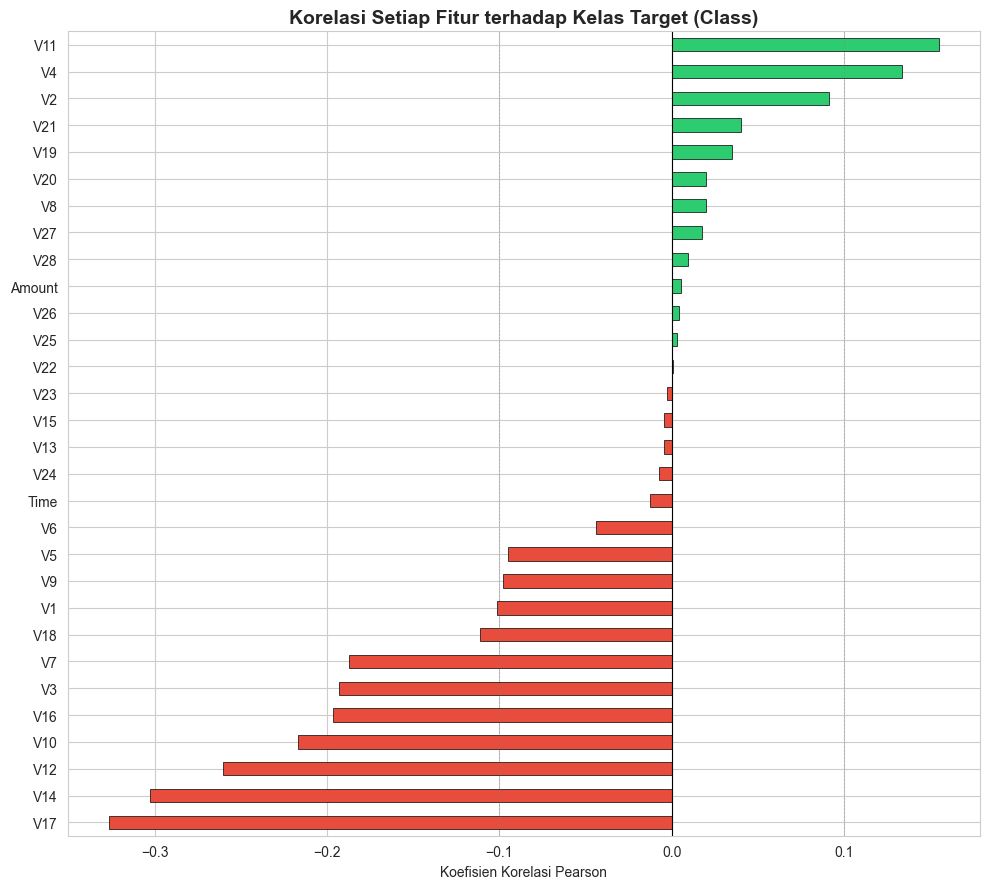


Top 5 fitur dengan korelasi POSITIF tertinggi terhadap fraud:
         V19 : +0.0348
         V21 : +0.0404
          V2 : +0.0913
          V4 : +0.1334
         V11 : +0.1549

Top 5 fitur dengan korelasi NEGATIF tertinggi terhadap fraud:
         V17 : -0.3265
         V14 : -0.3025
         V12 : -0.2606
         V10 : -0.2169
         V16 : -0.1965


In [11]:
# ============================================================
# 4.5 Korelasi Fitur terhadap Kelas Target
# ============================================================
korelasi_dengan_target = df.corr(numeric_only=True)['Class'].drop('Class').sort_values()

fig, ax = plt.subplots(figsize=(10, 9))

warna_korelasi = ['#e74c3c' if x < 0 else '#2ecc71' for x in korelasi_dengan_target]
korelasi_dengan_target.plot(kind='barh', color=warna_korelasi, ax=ax, edgecolor='black', linewidth=0.5)

ax.set_title('Korelasi Setiap Fitur terhadap Kelas Target (Class)', fontsize=14, fontweight='bold')
ax.set_xlabel('Koefisien Korelasi Pearson')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.axvline(x=0.1, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
ax.axvline(x=-0.1, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\nTop 5 fitur dengan korelasi POSITIF tertinggi terhadap fraud:")
for fitur, nilai in korelasi_dengan_target.tail(5).items():
    print(f"  {fitur:>10} : {nilai:+.4f}")

print("\nTop 5 fitur dengan korelasi NEGATIF tertinggi terhadap fraud:")
for fitur, nilai in korelasi_dengan_target.head(5).items():
    print(f"  {fitur:>10} : {nilai:+.4f}")

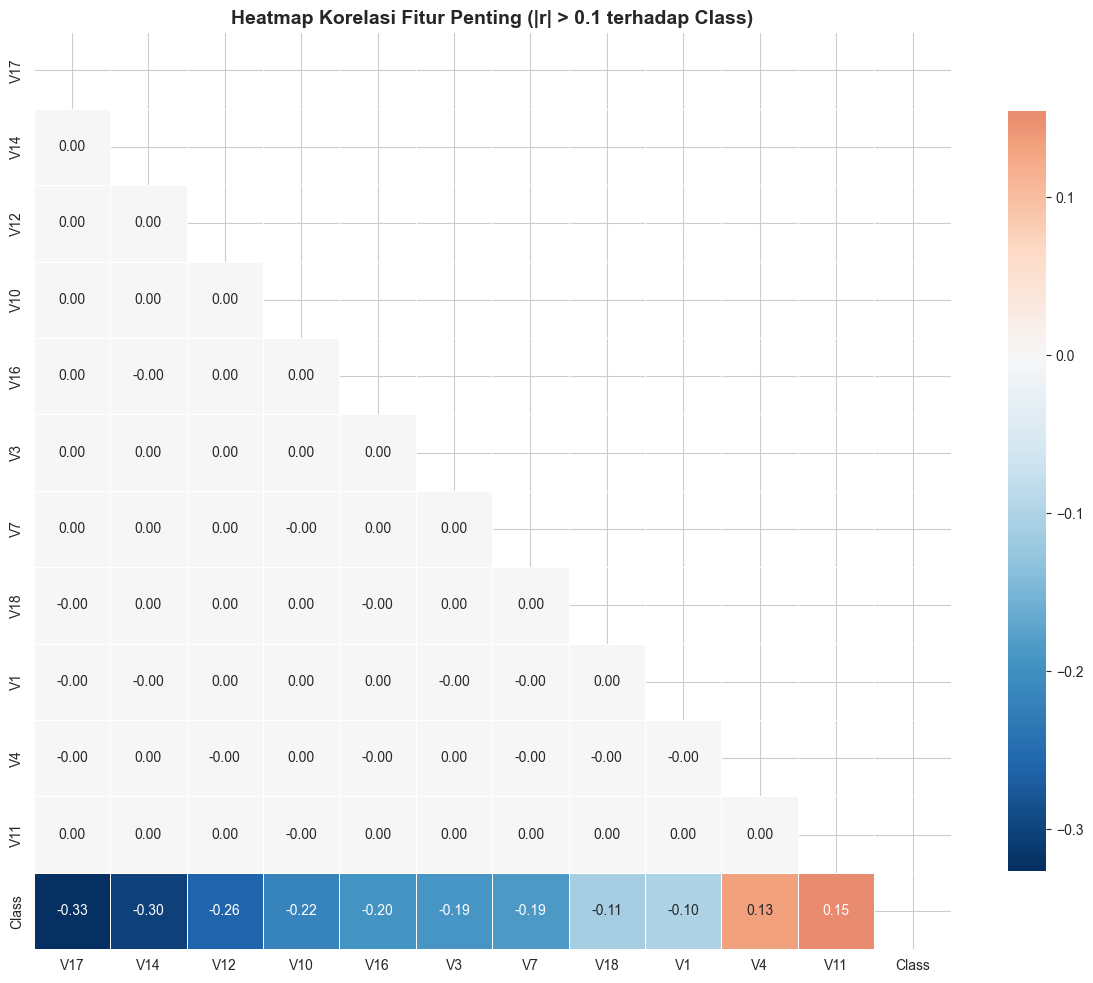

In [12]:
# ============================================================
# 4.6 Heatmap Korelasi antar Fitur (subset penting)
# ============================================================
# Memilih fitur dengan korelasi absolut > 0.1 terhadap target
fitur_penting = korelasi_dengan_target[abs(korelasi_dengan_target) > 0.1].index.tolist()
fitur_penting.append('Class')

fig, ax = plt.subplots(figsize=(12, 10))
matriks_korelasi = df[fitur_penting].corr(numeric_only=True)
mask = np.triu(np.ones_like(matriks_korelasi, dtype=bool))  # Mask segitiga atas

sns.heatmap(matriks_korelasi, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)

ax.set_title('Heatmap Korelasi Fitur Penting (|r| > 0.1 terhadap Class)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

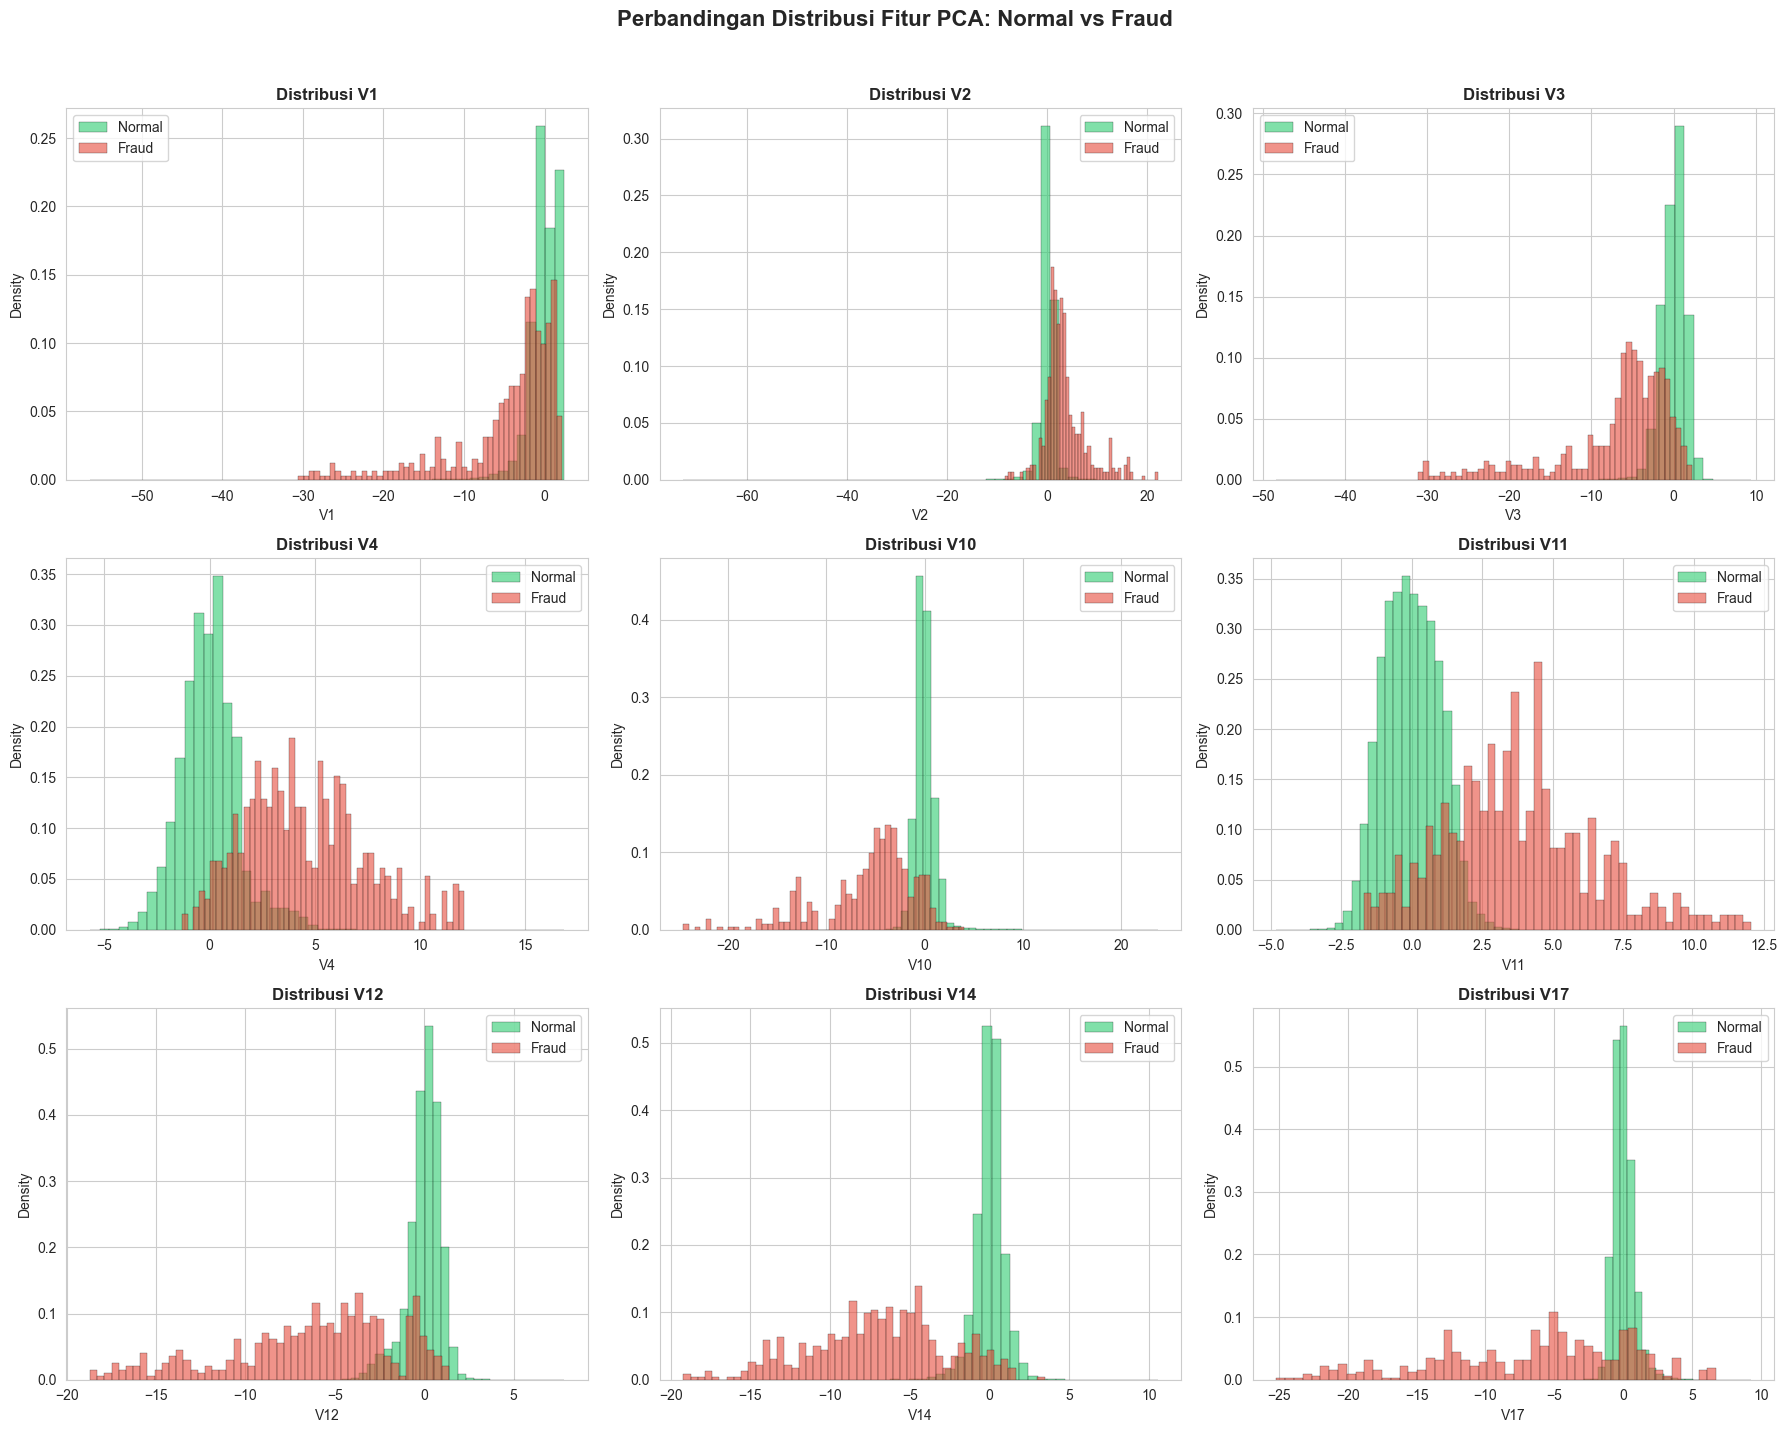

ℹ️ Fitur dengan distribusi yang jelas berbeda antara Normal dan Fraud
   menunjukkan potensi diskriminatif yang tinggi untuk model klasifikasi.


In [13]:
# ============================================================
# 4.7 Distribusi Fitur V1-V28 (Perbandingan Normal vs Fraud)
# ============================================================
# Menampilkan distribusi beberapa fitur PCA terpilih
fitur_terpilih = ['V1', 'V2', 'V3', 'V4', 'V10', 'V11', 'V12', 'V14', 'V17']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, fitur in enumerate(fitur_terpilih):
    axes[i].hist(df_normal[fitur], bins=50, alpha=0.6, color='#2ecc71',
                 label='Normal', density=True, edgecolor='black', linewidth=0.3)
    axes[i].hist(df_fraud[fitur], bins=50, alpha=0.6, color='#e74c3c',
                 label='Fraud', density=True, edgecolor='black', linewidth=0.3)
    axes[i].set_title(f'Distribusi {fitur}', fontsize=12, fontweight='bold')
    axes[i].legend()
    axes[i].set_xlabel(fitur)
    axes[i].set_ylabel('Density')

plt.suptitle('Perbandingan Distribusi Fitur PCA: Normal vs Fraud',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\u2139\ufe0f Fitur dengan distribusi yang jelas berbeda antara Normal dan Fraud")
print("   menunjukkan potensi diskriminatif yang tinggi untuk model klasifikasi.")

In [14]:
# ============================================================
# 4.8 Statistik Deskriptif per Kelas
# ============================================================
print("=" * 50)
print("STATISTIK TRANSAKSI NORMAL (Class=0)")
print("=" * 50)
print(df_normal[['Amount', 'Time']].describe())

print("\n" + "=" * 50)
print("STATISTIK TRANSAKSI FRAUD (Class=1)")
print("=" * 50)
print(df_fraud[['Amount', 'Time']].describe())

print("\n\u2139\ufe0f Ringkasan EDA:")
print("   1. Dataset sangat tidak seimbang (fraud ~0.17%)")
print("   2. Perlu penanganan khusus: SMOTE pada data training")
print("   3. Fitur Amount dan Time perlu distandarisasi")
print("   4. Beberapa fitur PCA menunjukkan pola berbeda antara fraud dan normal")
print(f"   5. Terdapat {jumlah_duplikat:,} baris duplikat yang perlu dihapus")

STATISTIK TRANSAKSI NORMAL (Class=0)
           Amount        Time
count 284315.0000 284315.0000
mean      88.2910  94838.2023
std      250.1051  47484.0158
min        0.0000      0.0000
25%        5.6500  54230.0000
50%       22.0000  84711.0000
75%       77.0500 139333.0000
max    25691.1600 172792.0000

STATISTIK TRANSAKSI FRAUD (Class=1)
         Amount        Time
count  492.0000    492.0000
mean   122.2113  80746.8069
std    256.6833  47835.3651
min      0.0000    406.0000
25%      1.0000  41241.5000
50%      9.2500  75568.5000
75%    105.8900 128483.0000
max   2125.8700 170348.0000

ℹ️ Ringkasan EDA:
   1. Dataset sangat tidak seimbang (fraud ~0.17%)
   2. Perlu penanganan khusus: SMOTE pada data training
   3. Fitur Amount dan Time perlu distandarisasi
   4. Beberapa fitur PCA menunjukkan pola berbeda antara fraud dan normal
   5. Terdapat 1,081 baris duplikat yang perlu dihapus


# **5. Data Preprocessing**

Pada tahap ini, kita membersihkan dan mempersiapkan data agar siap digunakan untuk pelatihan model machine learning. Berdasarkan temuan pada tahap EDA, berikut langkah-langkah preprocessing yang akan dilakukan:

1. **Menghapus data duplikat** — Ditemukan baris duplikat pada EDA
2. **Standarisasi fitur** — `Amount` dan `Time` perlu distandarisasi agar seragam dengan V1-V28
3. **Memisahkan fitur dan label** — Pisahkan X (fitur) dan y (target)
4. **Membagi data train/test** — Dengan stratifikasi untuk menjaga proporsi kelas
5. **Penanganan ketidakseimbangan kelas (SMOTE)** — Hanya pada data training
6. **Menyimpan data hasil preprocessing** — Ke file CSV untuk digunakan pada kriteria selanjutnya

In [15]:
# ============================================================
# 5.1 Menghapus Data Duplikat
# ============================================================
jumlah_sebelum = len(df)
df = df.drop_duplicates()
jumlah_sesudah = len(df)
jumlah_dihapus_preprocessing = jumlah_sebelum - jumlah_sesudah

print("=" * 50)
print("TAHAP 1: MENGHAPUS DATA DUPLIKAT")
print("=" * 50)
print(f"Data sebelum hapus duplikat : {jumlah_sebelum:,}")
print(f"Data sesudah hapus duplikat : {jumlah_sesudah:,}")
print(f"Jumlah duplikat dihapus     : {jumlah_dihapus_preprocessing:,}")

TAHAP 1: MENGHAPUS DATA DUPLIKAT
Data sebelum hapus duplikat : 284,807
Data sesudah hapus duplikat : 283,726
Jumlah duplikat dihapus     : 1,081


In [16]:
# ============================================================
# 5.2 Standarisasi Fitur 'Amount' dan 'Time'
# ============================================================
# Fitur V1-V28 sudah hasil PCA (sudah terstandarisasi)
# Hanya 'Amount' dan 'Time' yang perlu distandarisasi

print("=" * 50)
print("TAHAP 2: STANDARISASI FITUR")
print("=" * 50)

penskalaan_amount = StandardScaler()
penskalaan_time = StandardScaler()

# Menampilkan perbandingan sebelum standarisasi
print("Sebelum standarisasi:")
print(f"  Amount \u2014 Mean: {df['Amount'].mean():.2f}, Std: {df['Amount'].std():.2f}")
print(f"  Time   \u2014 Mean: {df['Time'].mean():.2f}, Std: {df['Time'].std():.2f}")

df['Amount_Scaled'] = penskalaan_amount.fit_transform(df[['Amount']])
df['Time_Scaled'] = penskalaan_time.fit_transform(df[['Time']])

# Hapus kolom asli
df = df.drop(columns=['Amount', 'Time'])

print("\nSesudah standarisasi:")
print(f"  Amount_Scaled \u2014 Mean: {df['Amount_Scaled'].mean():.6f}, Std: {df['Amount_Scaled'].std():.6f}")
print(f"  Time_Scaled   \u2014 Mean: {df['Time_Scaled'].mean():.6f}, Std: {df['Time_Scaled'].std():.6f}")

print(f"\nJumlah kolom sekarang: {len(df.columns)}")
print(f"Daftar kolom: {list(df.columns)}")

TAHAP 2: STANDARISASI FITUR
Sebelum standarisasi:
  Amount — Mean: 88.47, Std: 250.40
  Time   — Mean: 94811.08, Std: 47481.05

Sesudah standarisasi:
  Amount_Scaled — Mean: -0.000000, Std: 1.000002
  Time_Scaled   — Mean: 0.000000, Std: 1.000002

Jumlah kolom sekarang: 31
Daftar kolom: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Amount_Scaled', 'Time_Scaled']


In [17]:
# ============================================================
# 5.3 Memisahkan Fitur dan Label
# ============================================================
print("=" * 50)
print("TAHAP 3: MEMISAHKAN FITUR DAN LABEL")
print("=" * 50)

X = df.drop(columns=['Class'])    # Fitur
y = df['Class']                    # Label target

print(f"Dimensi fitur (X) : {X.shape} \u2014 {X.shape[1]} fitur")
print(f"Dimensi label (y) : {y.shape}")
print(f"\nDistribusi label:")
print(f"  Normal (0) : {(y == 0).sum():,}")
print(f"  Fraud  (1) : {(y == 1).sum():,}")

TAHAP 3: MEMISAHKAN FITUR DAN LABEL
Dimensi fitur (X) : (283726, 30) — 30 fitur
Dimensi label (y) : (283726,)

Distribusi label:
  Normal (0) : 283,253
  Fraud  (1) : 473


In [18]:
# ============================================================
# 5.4 Membagi Data: Train dan Test (dengan Stratifikasi)
# ============================================================
print("=" * 50)
print("TAHAP 4: PEMBAGIAN DATA TRAIN DAN TEST")
print("=" * 50)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,      # Reproducibility
    stratify=y            # Menjaga proporsi kelas pada kedua subset
)

print(f"Ukuran data latih : {X_train.shape[0]:,} ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Ukuran data uji   : {X_test.shape[0]:,} ({X_test.shape[0]/len(df)*100:.1f}%)")

print(f"\nDistribusi kelas pada data latih:")
print(f"  Normal : {(y_train == 0).sum():,} ({(y_train == 0).sum()/len(y_train)*100:.4f}%)")
print(f"  Fraud  : {(y_train == 1).sum():,} ({(y_train == 1).sum()/len(y_train)*100:.4f}%)")

print(f"\nDistribusi kelas pada data uji:")
print(f"  Normal : {(y_test == 0).sum():,} ({(y_test == 0).sum()/len(y_test)*100:.4f}%)")
print(f"  Fraud  : {(y_test == 1).sum():,} ({(y_test == 1).sum()/len(y_test)*100:.4f}%)")

TAHAP 4: PEMBAGIAN DATA TRAIN DAN TEST


Ukuran data latih : 226,980 (80.0%)
Ukuran data uji   : 56,746 (20.0%)

Distribusi kelas pada data latih:
  Normal : 226,602 (99.8335%)
  Fraud  : 378 (0.1665%)

Distribusi kelas pada data uji:
  Normal : 56,651 (99.8326%)
  Fraud  : 95 (0.1674%)


TAHAP 5: PENANGANAN KETIDAKSEIMBANGAN KELAS (SMOTE)


Sebelum SMOTE:
  Normal : 226,602
  Fraud  : 378
  Total  : 226,980

Sesudah SMOTE:
  Normal : 226,602
  Fraud  : 226,602
  Total  : 453,204


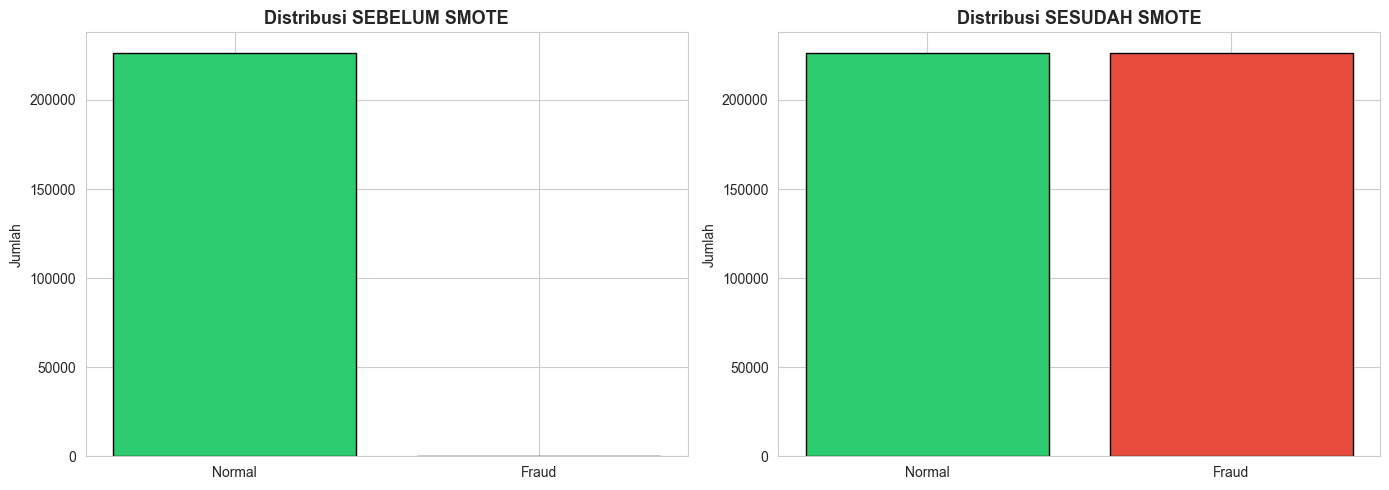

In [19]:
# ============================================================
# 5.5 Penanganan Ketidakseimbangan Kelas dengan SMOTE
# ============================================================
# PENTING: SMOTE hanya diterapkan pada data TRAINING,
# TIDAK pada data test agar evaluasi tetap realistis

print("=" * 50)
print("TAHAP 5: PENANGANAN KETIDAKSEIMBANGAN KELAS (SMOTE)")
print("=" * 50)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Sebelum SMOTE:")
print(f"  Normal : {(y_train == 0).sum():,}")
print(f"  Fraud  : {(y_train == 1).sum():,}")
print(f"  Total  : {len(y_train):,}")

print("\nSesudah SMOTE:")
print(f"  Normal : {(y_train_resampled == 0).sum():,}")
print(f"  Fraud  : {(y_train_resampled == 1).sum():,}")
print(f"  Total  : {len(y_train_resampled):,}")

# Visualisasi perbandingan sebelum dan sesudah SMOTE
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].bar(['Normal', 'Fraud'], [sum(y_train == 0), sum(y_train == 1)],
          color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax[0].set_title('Distribusi SEBELUM SMOTE', fontsize=13, fontweight='bold')
ax[0].set_ylabel('Jumlah')

ax[1].bar(['Normal', 'Fraud'],
          [sum(y_train_resampled == 0), sum(y_train_resampled == 1)],
          color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax[1].set_title('Distribusi SESUDAH SMOTE', fontsize=13, fontweight='bold')
ax[1].set_ylabel('Jumlah')

plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# 5.6 Menyimpan Data yang Sudah Dipreproses
# ============================================================
import os

print("=" * 50)
print("TAHAP 6: MENYIMPAN HASIL PREPROCESSING")
print("=" * 50)

jalur_simpan = 'creditcard_preprocessing/'
os.makedirs(jalur_simpan, exist_ok=True)

# Menyimpan data training (sudah SMOTE) dan data test
X_train_resampled.to_csv(f'{jalur_simpan}X_train.csv', index=False)
X_test.to_csv(f'{jalur_simpan}X_test.csv', index=False)
y_train_resampled.to_csv(f'{jalur_simpan}y_train.csv', index=False)
y_test.to_csv(f'{jalur_simpan}y_test.csv', index=False)

print(f"\u2705 Data berhasil disimpan ke folder '{jalur_simpan}'")
print(f"")
print(f"   File yang disimpan:")
print(f"   1. X_train.csv : {X_train_resampled.shape} \u2014 Fitur training (sudah SMOTE)")
print(f"   2. X_test.csv  : {X_test.shape} \u2014 Fitur testing")
print(f"   3. y_train.csv : {y_train_resampled.shape} \u2014 Label training (sudah SMOTE)")
print(f"   4. y_test.csv  : {y_test.shape} \u2014 Label testing")

# Verifikasi file tersimpan
print(f"\n   Verifikasi file:")
for file in os.listdir(jalur_simpan):
    ukuran = os.path.getsize(os.path.join(jalur_simpan, file))
    print(f"   - {file} ({ukuran/1024/1024:.2f} MB)")

print("\n" + "=" * 50)
print("\u2705 SELURUH TAHAPAN PREPROCESSING SELESAI")
print("=" * 50)
print("\nData siap digunakan untuk pelatihan model pada Kriteria 2.")

TAHAP 6: MENYIMPAN HASIL PREPROCESSING


✅ Data berhasil disimpan ke folder 'creditcard_preprocessing/'

   File yang disimpan:
   1. X_train.csv : (453204, 30) — Fitur training (sudah SMOTE)
   2. X_test.csv  : (56746, 30) — Fitur testing
   3. y_train.csv : (453204,) — Label training (sudah SMOTE)
   4. y_test.csv  : (56746,) — Label testing

   Verifikasi file:
   - X_test.csv (30.00 MB)
   - X_train.csv (246.28 MB)
   - y_test.csv (0.16 MB)
   - y_train.csv (1.30 MB)

✅ SELURUH TAHAPAN PREPROCESSING SELESAI

Data siap digunakan untuk pelatihan model pada Kriteria 2.
